In [66]:
# ruff: noqa: D101
# ruff: noqa: D102
# ruff: noqa: D103
# ruff: noqa: D106

import astropy.units as u
import jax.numpy as jnp
import scarlet2
from numpy.testing import assert_allclose
from scarlet2.frame import get_affine, _flip_matrix, _rot_matrix, _wcs_default
from scarlet2 import ArrayPSF
from scarlet2.morphology import GaussianMorphology
from scarlet2.measure import Moments
import matplotlib.pyplot as plt

# resampling renderer to test
cls = scarlet2.renderer.ResamplingRenderer

# create a Gaussian as model
T = 10
eps = jnp.array((0.5, 0.3))
model = GaussianMorphology(size=T, ellipticity=eps, shape=(150,151))()[None, ...] # test even & odd
g = scarlet2.measure.Moments(component=model[0], N=2)

# make a Frame
model_frame = scarlet2.Frame(scarlet2.Box(model.shape))

In [68]:
def test_rescale():
    # how does this model look if we change the WCS scale
    # if scale becomes larger, the image gets smaller
    scale = 3.1
    shape = (int(model.shape[-2] / scale) + 1, int(model.shape[-1] / scale))
    wcs_obs = _wcs_default(shape)
    m = scarlet2.frame.get_affine(wcs_obs)
    m = scale * m
    wcs_obs.wcs.pc = m

    obs_frame = scarlet2.Frame(scarlet2.Box(shape), wcs=wcs_obs)
    renderer = cls(model_frame, obs_frame)
    model_ = renderer(model)

    # print(renderer)
    # fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    # ax[0].imshow(model[0])
    # ax[1].imshow(model_[0])

    # undo resizing
    g_obs = Moments(model_[0])
    g_obs.resize(scale)
    assert_allclose(g_obs.flux, g.flux, atol=3e-3)
    shift_ = jnp.asarray(g_obs.centroid) - jnp.asarray(obs_frame.bbox.spatial.center)
    assert_allclose(shift_, (0,0), atol=1e-4)
    assert_allclose(g_obs.size, g.size, rtol=3e-5)
    assert_allclose(g_obs.ellipticity, g.ellipticity, atol=3e-5)

test_rescale()

In [69]:
def test_rotate():
    # how does this model look if we rotated the WCS scale
    # because we change the frame, this will appear as a rotation in the opposite direction
    shape = model.shape
    phi = (30 * u.deg).to(u.rad).value
    wcs_obs = _wcs_default(shape)
    m = scarlet2.frame.get_affine(wcs_obs)
    r = _rot_matrix(phi)
    m = r @ m
    wcs_obs.wcs.pc = m

    obs_frame = scarlet2.Frame(scarlet2.Box(shape), wcs=wcs_obs)
    renderer = cls(model_frame, obs_frame)
    model_ = renderer(model)

    # rotate to correct for the counter-rotation of the frame
    g_obs = Moments(model_[0])
    g_obs.rotate(phi)
    assert_allclose(g_obs.flux, g.flux, atol=3e-3)
    assert_allclose(g_obs.centroid, g.centroid, atol=1e-4)
    assert_allclose(g_obs.size, g.size, rtol=3e-5)
    assert_allclose(g_obs.ellipticity, g.ellipticity, atol=3e-5)

test_rotate()

ResamplingRenderer(
  padding=4,
  scale=1.0,
  angle=0.0,
  handedness=-1,
  shift=(0.0, 0.0),
  has_psf_in=False,
  has_psf_out=False
)


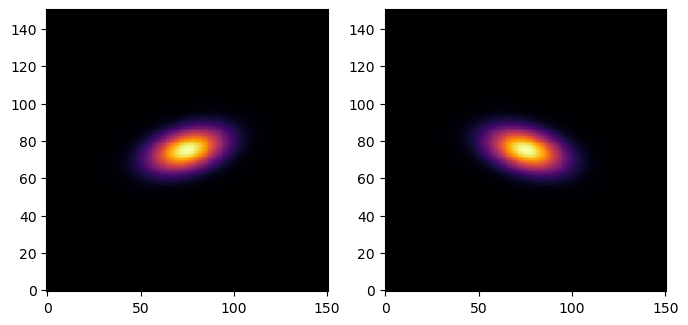

In [42]:
def test_flip():
    shape = model.shape
    wcs_obs = _wcs_default(shape)
    m = scarlet2.frame.get_affine(wcs_obs)
    f = _flip_matrix(-1)
    m = f @ m
    wcs_obs.wcs.pc = m

    obs_frame = scarlet2.Frame(scarlet2.Box(shape), wcs=wcs_obs)
    renderer = cls(model_frame, obs_frame)
    model_ = renderer(model)

    print(renderer)
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(model[0])
    ax[1].imshow(model_[0])

    # undo the flip
    g_obs = Moments(model_[0])
    g_obs.flipud()
    assert_allclose(g_obs.flux, g.flux, atol=3e-3)
    assert_allclose(g_obs.centroid, g.centroid, atol=1e-4)
    assert_allclose(g_obs.size, g.size, rtol=3e-5)
    assert_allclose(g_obs.ellipticity, g.ellipticity, atol=3e-5)

test_flip()

In [70]:

def test_convolution():
    # create model PSF and convolve g
    T_p = 0.7
    eps_p = None
    psf = GaussianMorphology(size=T_p, ellipticity=eps_p)()
    psf /= psf.sum()
    p = Moments(psf, N=2)
    psf = ArrayPSF(psf[None,...])
    model_frame_ = scarlet2.Frame(scarlet2.Box(model.shape), psf=psf)

    # create obs PSF
    T_obs, eps_obs = 5, jnp.array((-0.1, 0.1))
    psf_obs = GaussianMorphology(size=T_obs, ellipticity=eps_obs)()
    psf_obs /= psf_obs.sum()
    p_obs = Moments(psf_obs, N=2)
    psf_obs = ArrayPSF(psf_obs[None,...])

    # render: deconvolve, reconcolve
    shape = model.shape
    obs_frame = scarlet2.Frame(scarlet2.Box(shape), psf=psf_obs)
    renderer = cls(model_frame_, obs_frame)
    model_ = renderer(model)
    g_obs = Moments(model_[0])

    g_obs.deconvolve(p_obs).convolve(p)
    assert_allclose(g_obs.flux, g.flux, atol=3e-3)
    assert_allclose(g_obs.centroid, g.centroid, atol=1e-4)
    assert_allclose(g_obs.size, g.size, rtol=3e-5)
    assert_allclose(g_obs.ellipticity, g.ellipticity, atol=3e-5)

test_convolution()

In [71]:
def test_translation():
    shift = jnp.array((12, -1.9))
    shape = model.shape
    wcs_obs = _wcs_default(shape)
    wcs_obs.wcs.crpix += shift[::-1] # x/y

    shape = model.shape
    obs_frame = scarlet2.Frame(scarlet2.Box(shape), wcs=wcs_obs)
    renderer = cls(model_frame, obs_frame)
    model_ = renderer(model)

    g_obs = Moments(model_[0])
    shift_ = jnp.asarray(g_obs.centroid) - jnp.asarray(g.centroid)

    assert_allclose(g_obs.flux, g.flux, rtol=2e-3)
    assert_allclose(shift_, -shift, atol=1e-4)
    assert_allclose(g_obs.size, g.size, rtol=3e-5)
    assert_allclose(g_obs.ellipticity, g.ellipticity, atol=3e-5)


test_translation()

In [72]:
def test_all():
    scale = 2.1
    phi = (70 * u.deg).to(u.rad).value
    shift = jnp.array((1.4, -0.456))
    shape = (int(model.shape[1] // scale), int(model.shape[2] // scale))
    wcs_obs = _wcs_default(shape)
    m = get_affine(wcs_obs)
    wcs_obs.wcs.pc = scale * _rot_matrix(phi) @ _flip_matrix(-1) @ m
    wcs_obs.wcs.crpix += shift[::-1] # x/y

    # create model PSF and convolve g
    T_p = 1
    eps_p = None
    psf = GaussianMorphology(size=T_p, ellipticity=eps_p)()
    psf /= psf.sum()
    p = Moments(psf, N=2)
    psf = ArrayPSF(psf[None,...])
    model_frame_ = scarlet2.Frame(scarlet2.Box(model.shape), psf=psf)

    # obs PSF
    T_obs, eps_obs = 3, jnp.array((0.1, -0.1))
    psf_obs = GaussianMorphology(size=T_obs, ellipticity=eps_obs)()
    psf_obs /= psf_obs.sum()
    p_obs = Moments(psf_obs, N=2)
    psf_obs = ArrayPSF(psf_obs[None,...])

    obs_frame = scarlet2.Frame(scarlet2.Box(shape), psf=psf_obs, wcs=wcs_obs)
    renderer = cls(model_frame_, obs_frame)
    model_ = renderer(model)

    g_obs = Moments(model_[0])
    g_obs.deconvolve(p_obs).flipud().rotate(phi).resize(scale).convolve(p)
    shift_ = jnp.asarray(g_obs.centroid) - jnp.asarray(obs_frame.bbox.spatial.center)

    assert_allclose(g_obs.flux, g.flux, rtol=2e-3)
    assert_allclose(shift_, -shift, atol=1e-4)
    assert_allclose(g_obs.size, g.size, rtol=3e-5)
    assert_allclose(g_obs.ellipticity, g.ellipticity, atol=3e-5)

test_all()